# Interactive Fitter

In [1]:
%run ../../../setup_workspace.py # ../ means level up 

# Functions

In [2]:
def gaussian(x, A, x0, sigma):
    return A * np.exp(-(x - x0)**2 / (2 * sigma**2))

def voigt(x, A, x0, sigma, gamma):
    return A * voigt_profile(x - x0, sigma, gamma) / voigt_profile(0, sigma, gamma)

def linear(x, k, b):
    return k * x + b
    
def linear_2points(x, x1, y1, x2, y2):
    k = (y2 - y1) / (x2 - x1)
    b = y1 - k * x1

    return linear(x, k, b)

In [3]:
func_lib = {
    'gaussian': gaussian,
    'voigt': voigt
}

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import widgets, VBox, HBox, Layout
from IPython.display import display
from scipy.optimize import curve_fit
from collections import OrderedDict
import inspect

class Fitter:
    def __init__(self, x, y, lib):
        self.x = x
        self.y = y
        self.lib = lib
        self.comps = OrderedDict()
        self.colors = plt.cm.tab10(np.linspace(0, 1, 10))
        self.setup_ui()
        
    def setup_ui(self):
        self.selector = widgets.Dropdown(options=list(self.lib.keys()), description='Функция:')
        self.add_btn = widgets.Button(description='Добавить', button_style='success')
        self.add_btn.on_click(self.add)
        self.fit_btn = widgets.Button(description='Фитить', button_style='primary')
        self.fit_btn.on_click(self.fit)
        
        self.comps_box = widgets.VBox([])
        self.out = widgets.Output()
        
        display(VBox([HBox([self.selector, self.add_btn, self.fit_btn]), self.comps_box, self.out]))
        self.plot()
        
    def add(self, _):
        name = self.selector.value
        func = self.lib[name]
        
        sig = inspect.signature(func)
        params = [p for p in sig.parameters if p != 'x']
        
        widgs = []
        for p in params:
            w = widgets.FloatText(
                value=1.0, 
                description=f'{p}:', 
                layout=Layout(width='150px'),
                step=0.1  # шаг стрелочками 0.1
            )
            w.observe(self.plot, 'value')
            widgs.append(w)
        
        cb = widgets.Checkbox(value=True, description='показать', layout=Layout(width='90px'))
        cb.observe(self.plot, 'value')
        
        rem = widgets.Button(description='✖', layout=Layout(width='40px'), button_style='danger')
        
        comp_id = len(self.comps)
        self.comps[comp_id] = {
            'name': name, 'func': func, 'params': widgs, 'enabled': cb,
            'color': self.colors[comp_id % len(self.colors)]
        }
        
        rem.on_click(lambda _, cid=comp_id: self.remove(cid))
        
        self.comps_box.children += (HBox([widgets.HTML(f"<b>{name}</b>", layout=Layout(width='100px'))] + widgs + [cb, rem]),)
        self.plot()
        
    def remove(self, cid):
        del self.comps[cid]
        children = []
        for cid, c in self.comps.items():
            rem = widgets.Button(description='✖', layout=Layout(width='40px'), button_style='danger')
            rem.on_click(lambda _, cid=cid: self.remove(cid))
            children.append(HBox([widgets.HTML(f"<b>{c['name']}</b>", layout=Layout(width='100px'))] + 
                                c['params'] + [c['enabled'], rem]))
        self.comps_box.children = tuple(children)
        self.plot()
        
    def model(self, x, *params):
        y = np.zeros_like(x)
        idx = 0
        for c in self.comps.values():
            if c['enabled'].value:
                n = len(c['params'])
                y += c['func'](x, *params[idx:idx+n])
                idx += n
        return y
        
    def plot(self, _=None):
        self.out.clear_output(wait=True)
        with self.out:
            fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={'height_ratios': [3, 1]})
            
            ax1.plot(self.x, self.y, 'k.', markersize=2, label='data')
            
            y_total = np.zeros_like(self.x)
            for c in self.comps.values():
                if c['enabled'].value:
                    p = [w.value for w in c['params']]
                    yc = c['func'](self.x, *p)
                    y_total += yc
                    ax1.plot(self.x, yc, '--', color=c['color'], alpha=0.7, label=c['name'])
            
            ax1.plot(self.x, y_total, 'r-', linewidth=2, label='sum')
            ax1.legend()
            ax1.grid(True, alpha=0.3)
            
            ax2.plot(self.x, self.y - y_total, 'b-')
            ax2.axhline(0, color='k', ls='--', lw=0.5)
            ax2.grid(True, alpha=0.3)
            ax2.set_xlabel('x')
            
            plt.tight_layout()
            plt.show()
            
    def fit(self, _):
        p0 = []
        for c in self.comps.values():
            if c['enabled'].value:
                p0 += [w.value for w in c['params']]
        
        if not p0:
            return
        
        # Задаем границы: все параметры >= 0
        bounds = (0, np.inf)
        
        popt, _ = curve_fit(self.model, self.x, self.y, p0=p0, bounds=bounds)
        
        idx = 0
        for c in self.comps.values():
            if c['enabled'].value:
                n = len(c['params'])
                for j, w in enumerate(c['params']):
                    w.value = popt[idx + j]
                idx += n
        
        self.plot()

    def integrals(self):
        """Возвращает список площадей под каждой компонентой"""
        areas = []
        for c in self.comps.values():
            if c['enabled'].value:
                p = [w.value for w in c['params']]
                yc = c['func'](self.x, *p)
                areas.append(np.trapezoid(yc, self.x))
        return areas

    def get_params(self):
        """Экспортирует параметры всех компонент"""
        params = []
        for c in self.comps.values():
            if c['enabled'].value:
                params.append({
                    'name': c['name'],
                    'params': [w.value for w in c['params']]
                })
        return params
    
    def set_params(self, params):
        """Импортирует параметры в новый фиттер"""
        for p in params:
            self.selector.value = p['name']
            self.add(None)
            last_id = len(self.comps) - 1
            for w, val in zip(self.comps[last_id]['params'], p['params']):
                w.value = val
        self.plot()

    def get_model(self):
        """Возвращает функцию модели и начальные параметры"""
        def model_func(x, *params):
            y = np.zeros_like(x)
            idx = 0
            for c in self.comps.values():
                if c['enabled'].value:
                    n = len(c['params'])
                    y += c['func'](x, *params[idx:idx+n])
                    idx += n
            return y
        
        p0 = []
        for c in self.comps.values():
            if c['enabled'].value:
                p0 += [w.value for w in c['params']]
        
        return model_func, p0

# Analysis

### M4

'PCL_M4_100ms_1m_1'

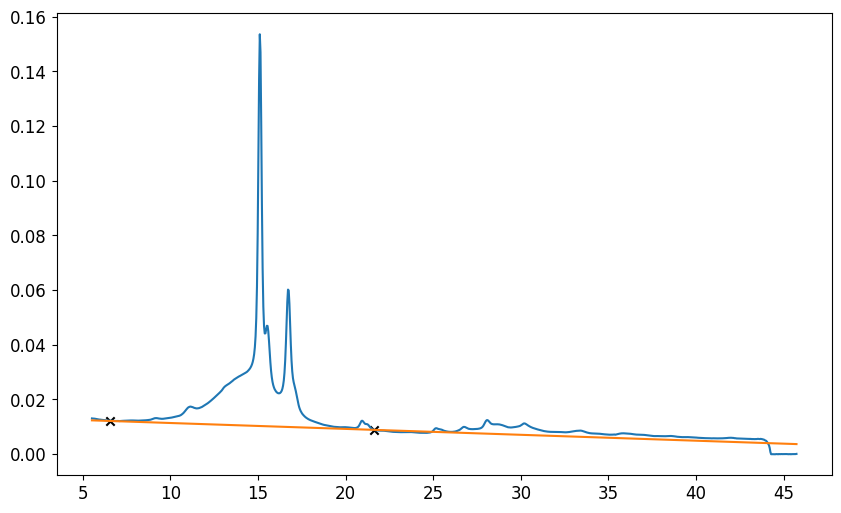

In [5]:
path = r"\\Synology\Data\2025\sc5665\id02\20250404\PROCESSED_DATA\PEG\PEG_20250405-141744\PEG_waxs_00108_00_ave.h5"

Exp = ID02_experiment(path)

q, I = Exp.get_1d_data()


plt.figure(figsize=(10,6))
plt.plot(q, I)

l = 25
r = 400

plt.scatter([q[l], q[r]], [I[l], I[r]], marker='x', color='black')

x = q[l:r]
y = I[l:r]

coef = 0.99

plt.plot(q, linear_2points(q, x[0], y[0], x[-1], y[-1]) * coef)

X = x
Y = y - linear_2points(x, x[0], y[0], x[-1], y[-1]) * coef

Exp.get_Title()

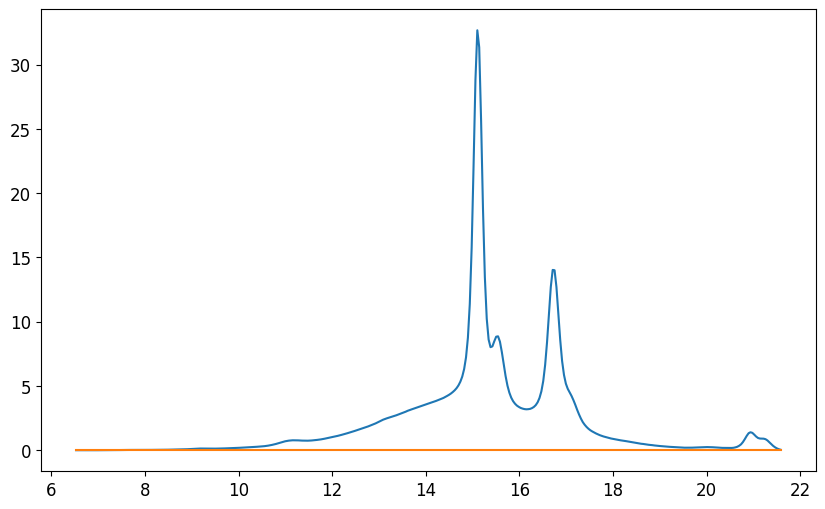

In [6]:
plt.plot(X, Y * X ** 2)
plt.plot(X, np.zeros(len(X)))

X_M4 = X
Y_M4 = Y * X ** 2

In [7]:
f_M4 = Fitter(X_M4, Y_M4, func_lib)

In [28]:
ints = f_M4.integrals()

Cr = np.sum(ints[1 : ])
All = np.sum(ints)

Crystallinity = Cr / All
Crystallinity

np.float64(0.4984351638573694)

### M3

'PCL_M3_100ms_1m_1'

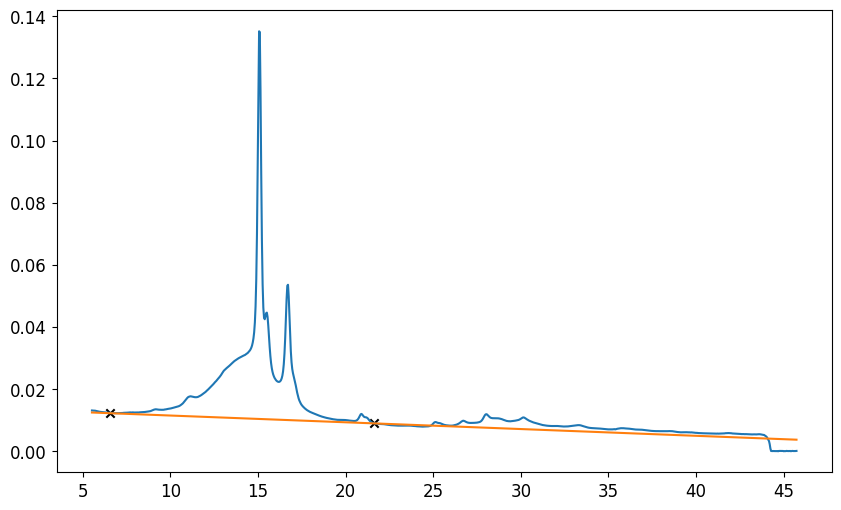

In [29]:
path = r"\\Synology\Data\2025\sc5665\id02\20250404\PROCESSED_DATA\PEG\PEG_20250405-141744\PEG_waxs_00096_00_ave.h5"

Exp = ID02_experiment(path)

q, I = Exp.get_1d_data()


plt.figure(figsize=(10,6))
plt.plot(q, I)

l = 25
r = 400

plt.scatter([q[l], q[r]], [I[l], I[r]], marker='x', color='black')

x = q[l:r]
y = I[l:r]

coef = 0.99

plt.plot(q, linear_2points(q, x[0], y[0], x[-1], y[-1]) * coef)

X = x
Y = y - linear_2points(x, x[0], y[0], x[-1], y[-1]) * coef

Exp.get_Title()

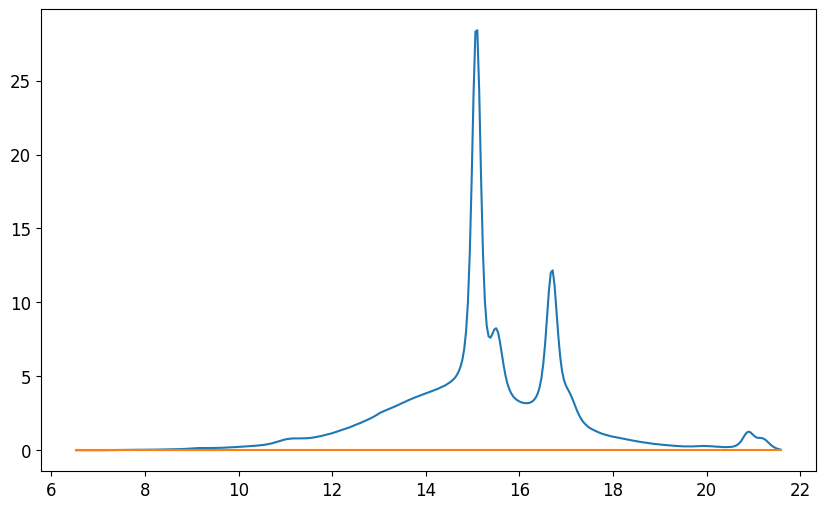

In [30]:
plt.plot(X, Y * X ** 2)
plt.plot(X, np.zeros(len(X)))

X_M3 = X
Y_M3 = Y * X ** 2

In [34]:
# Было:
f_M3 = Fitter(X_M3, Y_M3, func_lib)

# Загружаем параметры из предыдущего фиттера (f_old)
f_M3.set_params(f_M4.get_params())

In [35]:
ints = f_M3.integrals()

Cr = np.sum(ints[ : -1])
All = np.sum(ints)

Crystallinity = Cr / All
Crystallinity

np.float64(0.4403702270712897)

### M2

'PCL_M2_100ms_1m_1'

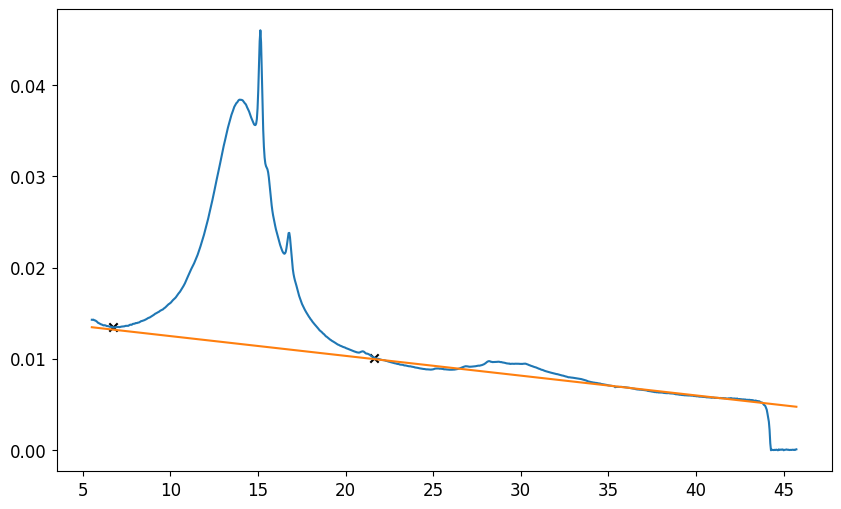

In [53]:
path = r"\\Synology\Data\2025\sc5665\id02\20250404\PROCESSED_DATA\PEG\PEG_20250405-141744\PEG_waxs_00083_00_ave.h5"

Exp = ID02_experiment(path)

q, I = Exp.get_1d_data()


plt.figure(figsize=(10,6))
plt.plot(q, I)

l = 30
r = 400

plt.scatter([q[l], q[r]], [I[l], I[r]], marker='x', color='black')

x = q[l:r]
y = I[l:r]

coef = 0.98

plt.plot(q, linear_2points(q, x[0], y[0], x[-1], y[-1]) * coef)

X = x
Y = y - linear_2points(x, x[0], y[0], x[-1], y[-1]) * coef

Exp.get_Title()

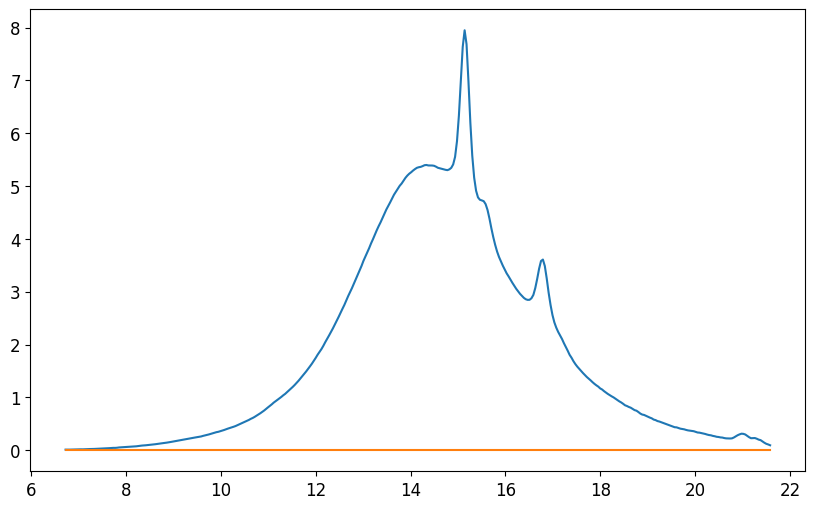

In [54]:
plt.plot(X, Y * X ** 2)
plt.plot(X, np.zeros(len(X)))

X_M2 = X
Y_M2 = Y * X ** 2

In [55]:
# Было:
f_M2 = Fitter(X_M2, Y_M2, func_lib)

# Загружаем параметры из предыдущего фиттера (f_old)
f_M2.set_params(f_M3.get_params())

In [59]:
ints = f_M2.integrals()

Amorph = ints[0] + ints[4] + ints[-1]
All = np.sum(ints)

Crystallinity = 1 - Amorph / All
Crystallinity

np.float64(0.0764457015189497)

### M1

'PCL_M1_100ms_1m_1'

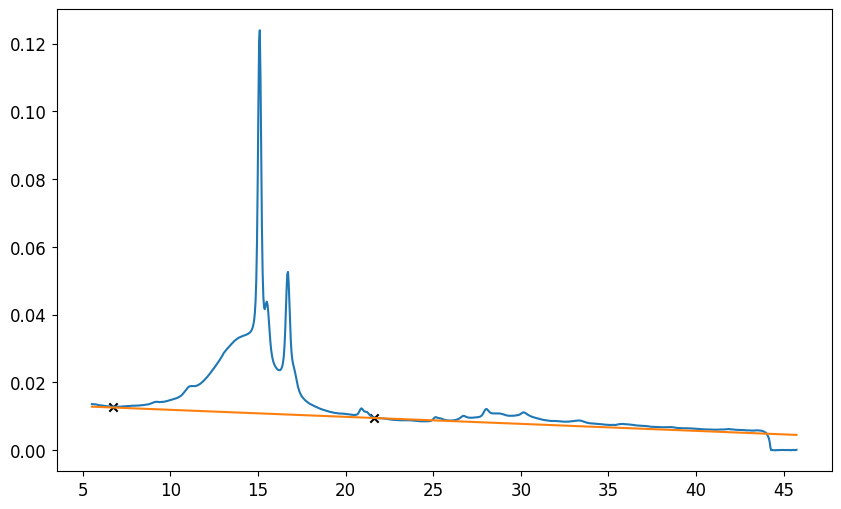

In [60]:
path = r"\\Synology\Data\2025\sc5665\id02\20250404\PROCESSED_DATA\PEG\PEG_20250405-141744\PEG_waxs_00071_00_ave.h5"

Exp = ID02_experiment(path)

q, I = Exp.get_1d_data()


plt.figure(figsize=(10,6))
plt.plot(q, I)

l = 30
r = 400

plt.scatter([q[l], q[r]], [I[l], I[r]], marker='x', color='black')

x = q[l:r]
y = I[l:r]

coef = 0.98

plt.plot(q, linear_2points(q, x[0], y[0], x[-1], y[-1]) * coef)

X = x
Y = y - linear_2points(x, x[0], y[0], x[-1], y[-1]) * coef

Exp.get_Title()

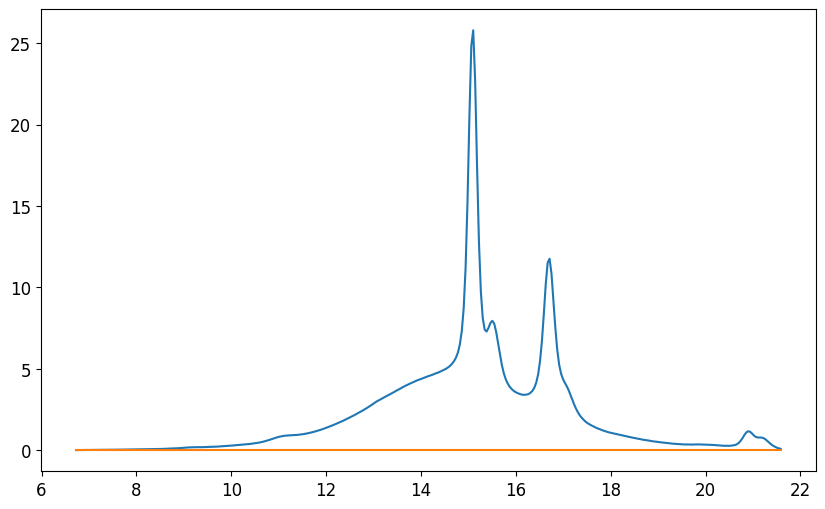

In [61]:
plt.plot(X, Y * X ** 2)
plt.plot(X, np.zeros(len(X)))

X_M1 = X
Y_M1 = Y * X ** 2

In [62]:
# Было:
f_M1 = Fitter(X_M1, Y_M1, func_lib)

# Загружаем параметры из предыдущего фиттера (f_old)
f_M1.set_params(f_M3.get_params())

In [63]:
ints = f_M1.integrals()

Cr = np.sum(ints[ : -1])
All = np.sum(ints)

Crystallinity = Cr / All
Crystallinity

np.float64(0.36541722723576836)

In [64]:
ints


[np.float64(0.09844471017091072),
 np.float64(6.237712619321673),
 np.float64(0.9158581779627495),
 np.float64(3.002540528944645),
 np.float64(1.3116296169139174),
 np.float64(0.4249835117651754),
 np.float64(0.12140621493022388),
 np.float64(21.034672415711682)]

### M3 - PEG 5%

'M3_PEG_5perc_100ms'

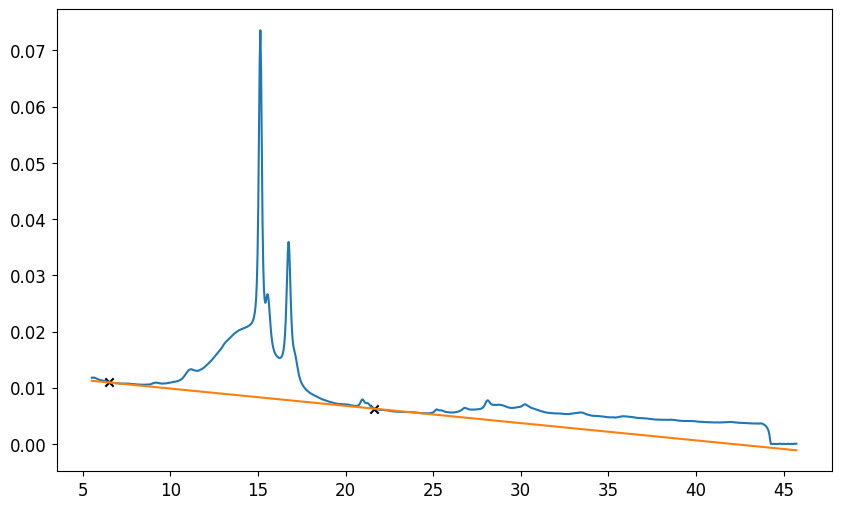

In [65]:
path = r"\\Synology\Data\2025\sc5665\id02\20250404\PROCESSED_DATA\PEG\PEG_20250405-141744\PEG_waxs_00029_00_ave.h5"

Exp = ID02_experiment(path)

q, I = Exp.get_1d_data()


plt.figure(figsize=(10,6))
plt.plot(q, I)

l = 25
r = 400

plt.scatter([q[l], q[r]], [I[l], I[r]], marker='x', color='black')

x = q[l:r]
y = I[l:r]

coef = 0.99

plt.plot(q, linear_2points(q, x[0], y[0], x[-1], y[-1]) * coef)

X = x
Y = y - linear_2points(x, x[0], y[0], x[-1], y[-1]) * coef

Exp.get_Title()

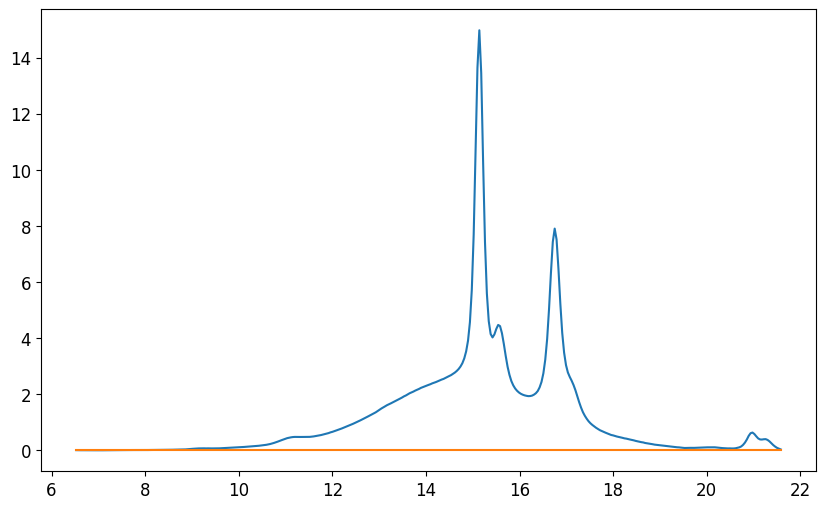

In [66]:
plt.plot(X, Y * X ** 2)
plt.plot(X, np.zeros(len(X)))

X_M3_5perc = X
Y_M3_5perc = Y * X ** 2

In [67]:
# Было:
f_M3_5perc = Fitter(X_M3_5perc, Y_M3_5perc, func_lib)

# Загружаем параметры из предыдущего фиттера (f_old)
f_M3_5perc.set_params(f_M3.get_params())

In [68]:
ints = f_M3_5perc.integrals()

Cr = np.sum(ints[ : -1])
All = np.sum(ints)

Crystallinity = Cr / All
Crystallinity

np.float64(0.41778458187165746)

### M3 - PEG 10%

'M3_PEG_10perc_100ms'

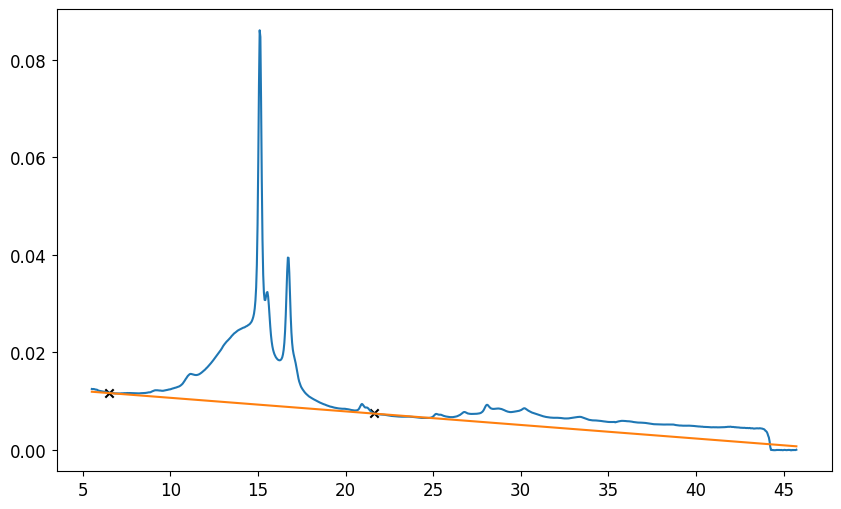

In [69]:
path = r"\\Synology\Data\2025\sc5665\id02\20250404\PROCESSED_DATA\PEG\PEG_20250405-141744\PEG_waxs_00038_00_ave.h5"

Exp = ID02_experiment(path)

q, I = Exp.get_1d_data()


plt.figure(figsize=(10,6))
plt.plot(q, I)

l = 25
r = 400

plt.scatter([q[l], q[r]], [I[l], I[r]], marker='x', color='black')

x = q[l:r]
y = I[l:r]

coef = 0.99

plt.plot(q, linear_2points(q, x[0], y[0], x[-1], y[-1]) * coef)

X = x
Y = y - linear_2points(x, x[0], y[0], x[-1], y[-1]) * coef

Exp.get_Title()

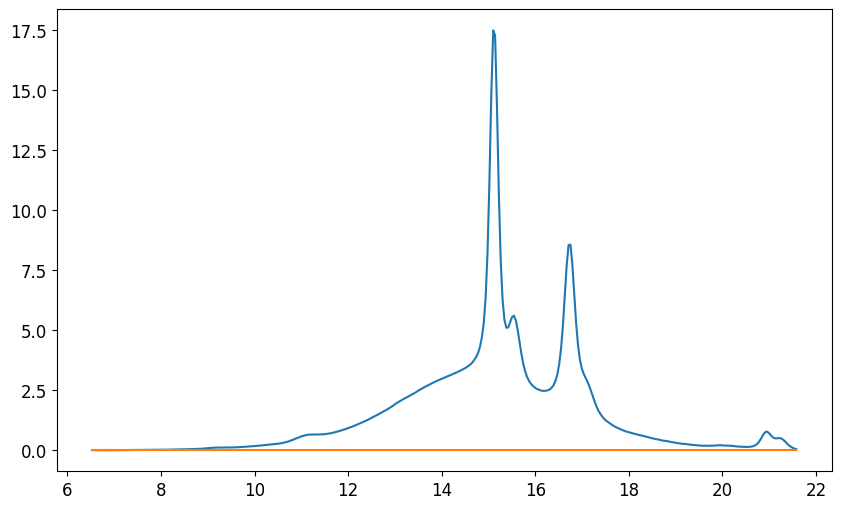

In [70]:
plt.plot(X, Y * X ** 2)
plt.plot(X, np.zeros(len(X)))

X_M3_10perc = X
Y_M3_10perc = Y * X ** 2

In [71]:
# Было:
f_M3_10perc = Fitter(X_M3_10perc, Y_M3_10perc, func_lib)

# Загружаем параметры из предыдущего фиттера (f_old)
f_M3_10perc.set_params(f_M3_5perc.get_params())

In [72]:
ints = f_M3_10perc.integrals()

Cr = np.sum(ints[ : -1])
All = np.sum(ints)

Crystallinity = Cr / All
Crystallinity

np.float64(0.3737403205931655)

### M3 - 15%

'M3_PEG_15perc_100ms'

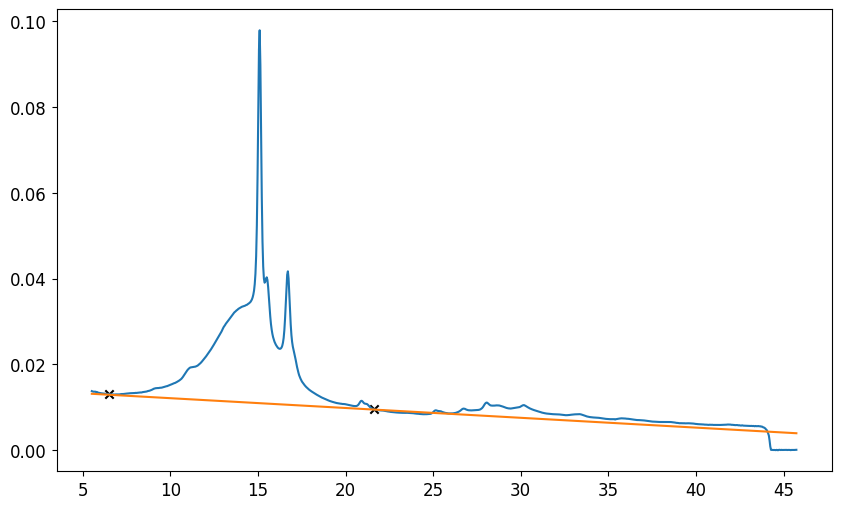

In [73]:
path = r"\\Synology\Data\2025\sc5665\id02\20250404\PROCESSED_DATA\PEG\PEG_20250405-141744\PEG_waxs_00045_00_ave.h5"

Exp = ID02_experiment(path)

q, I = Exp.get_1d_data()


plt.figure(figsize=(10,6))
plt.plot(q, I)

l = 25
r = 400

plt.scatter([q[l], q[r]], [I[l], I[r]], marker='x', color='black')

x = q[l:r]
y = I[l:r]

coef = 0.99

plt.plot(q, linear_2points(q, x[0], y[0], x[-1], y[-1]) * coef)

X = x
Y = y - linear_2points(x, x[0], y[0], x[-1], y[-1]) * coef

Exp.get_Title()

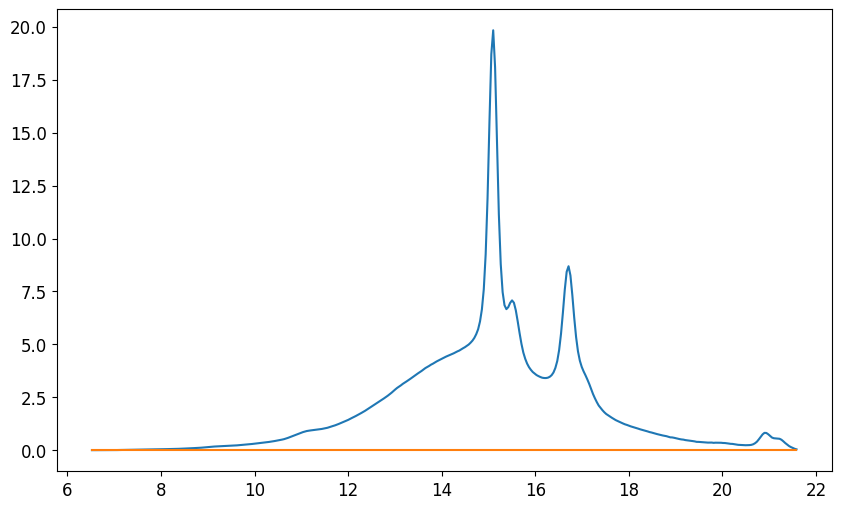

In [74]:
plt.plot(X, Y * X ** 2)
plt.plot(X, np.zeros(len(X)))

X_M3_15perc = X
Y_M3_15perc = Y * X ** 2

In [76]:
# Было:
f_M3_15perc = Fitter(X_M3_15perc, Y_M3_15perc, func_lib)

# Загружаем параметры из предыдущего фиттера (f_old)
f_M3_15perc.set_params(f_M3_10perc.get_params())

In [77]:
ints = f_M3_15perc.integrals()

Cr = np.sum(ints[ : -1])
All = np.sum(ints)

Crystallinity = Cr / All
Crystallinity

np.float64(0.28202380219868894)

### M3 - 20%

'M3_PEG_20perc_100ms'

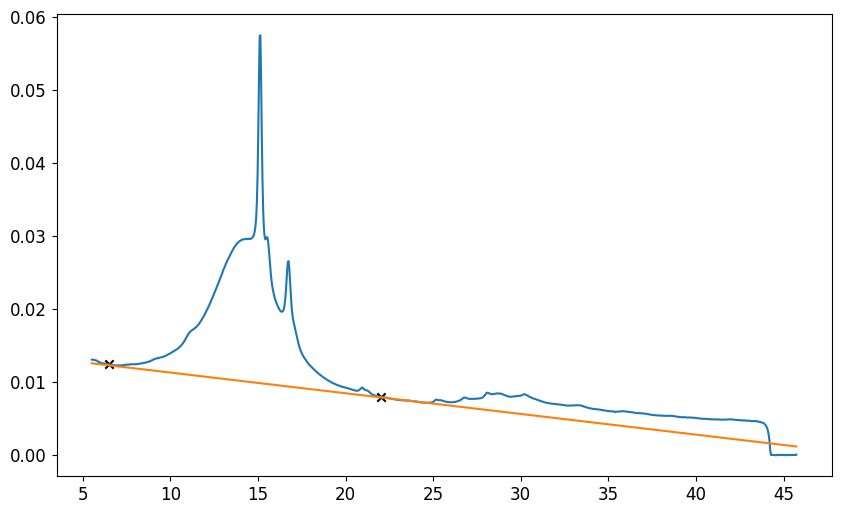

In [83]:
path = r"\\Synology\Data\2025\sc5665\id02\20250404\PROCESSED_DATA\PEG\PEG_20250405-141744\PEG_waxs_00052_00_ave.h5"

Exp = ID02_experiment(path)

q, I = Exp.get_1d_data()


plt.figure(figsize=(10,6))
plt.plot(q, I)

l = 25
r = 410

plt.scatter([q[l], q[r]], [I[l], I[r]], marker='x', color='black')

x = q[l:r]
y = I[l:r]

coef = 0.99

plt.plot(q, linear_2points(q, x[0], y[0], x[-1], y[-1]) * coef)

X = x
Y = y - linear_2points(x, x[0], y[0], x[-1], y[-1]) * coef

Exp.get_Title()

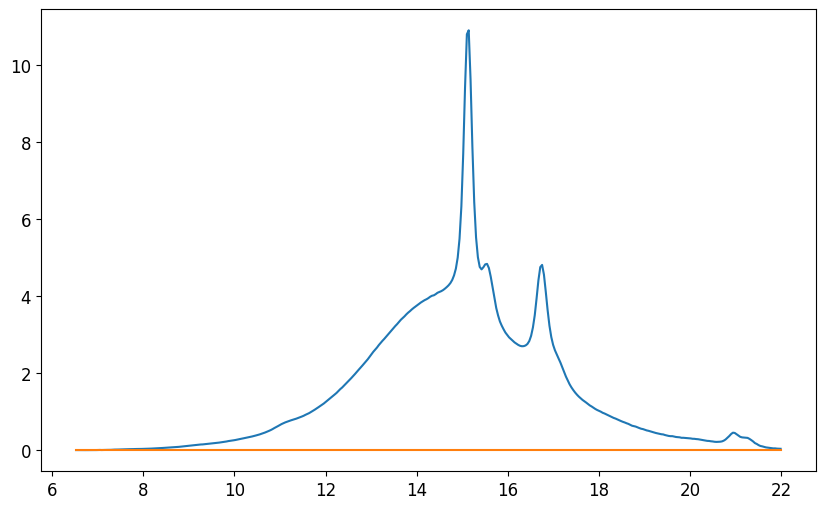

In [84]:
plt.plot(X, Y * X ** 2)
plt.plot(X, np.zeros(len(X)))

X_M3_20perc = X
Y_M3_20perc = Y * X ** 2

In [85]:
# Было:
f_M3_20perc = Fitter(X_M3_20perc, Y_M3_20perc, func_lib)

# Загружаем параметры из предыдущего фиттера (f_old)
f_M3_20perc.set_params(f_M3_15perc.get_params())

In [88]:
ints = f_M3_20perc.integrals()

Amorph = ints[0] + ints[4] + ints[-1]
All = np.sum(ints)

Crystallinity = 1 - Amorph / All
Crystallinity

np.float64(0.19498856263887931)

In [87]:
ints

[np.float64(3.3260296107555716),
 np.float64(2.2989462556338616),
 np.float64(0.710250054893003),
 np.float64(1.352682248319452),
 np.float64(5.786153381064326),
 np.float64(0.08264452645831419),
 np.float64(0.03816279480579072),
 np.float64(9.394612251700504)]